# Assignment 2: Milestone I Natural Language Processing
## Task 2&3
#### Student Name: Prathibha Magesh
#### Student ID: s3859590

Environment: Python 3 and Jupyter notebook

Libraries used: 
* pandas
* re
* numpy
* sklearn 
* gensim 
* scipy 
* matplotlib 

## Introduction

### Task 2: Generating Feature Representations for Clothing Reviews

This task focuses on converting cleaned customer reviews into numerical features that can be used in machine learning classification models. Since raw text is not directly usable by models, we apply three widely used representation techniques to convert text into structured vectors:

- **Bag-of-Words (BoW)** Count of words from a predefined vocabulary.
- **Unweighted Word Embeddings** Average of pre-trained word vectors for all words in a review.
- **TF-IDF Weighted Embeddings** Weighted average of word vectors using term importance scores.


## Importing libraries 

In [1]:
#Importing required libraries
import pandas as pd
import numpy as np
import re
from collections import Counter
from tqdm import tqdm

# Text vectorisation
from sklearn.feature_extraction.text import TfidfVectorizer

# Word embedding models
import gensim.downloader as api

# For handling sparse matrices (optional, for TF-IDF)
from scipy.sparse import csr_matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


## Task 2. Generating Feature Representations for Clothing Items Reviews

### 2.1 Bag-of-Words (Count Vector) Representation

This method represents each review as a sparse vector indicating how often each word in the vocabulary occurs in that review. It does not consider grammar or order but provides a useful structure for traditional classifiers.

Steps:
- Load the cleaned processed.csv file and vocab.txt.
- For each review, tokenize the text and count the frequency of each word.
- Use the vocabulary indices to format each review as (#review_index,word_index:count,...)
- Save the results in count_vectors.txt.

In [2]:
# Load processed reviews
df = pd.read_csv("processed.csv")

# Load vocab
vocab_dict = {}
with open("vocab.txt", "r") as f:
    for line in f:
        word, idx = line.strip().split(":")
        vocab_dict[word] = int(idx)

# Generate count vectors
count_vectors = []
for i, row in df.iterrows():
    text = row['processed_text']
    if not isinstance(text, str) or not text.strip():
        continue
    tokens = text.split()
    word_counts = Counter(tokens)

    vector_parts = []
    for word, count in word_counts.items():
        if word in vocab_dict:
            vector_parts.append(f"{vocab_dict[word]}:{count}")

    vector_parts.sort(key=lambda x: int(x.split(":")[0]))
    line = f"#{i}," + ",".join(vector_parts)
    count_vectors.append(line)

In [3]:
# Save to file
with open("count_vectors.txt", "w") as f:
    for line in count_vectors:
        f.write(line + "\n")
print("Saved count_vectors.txt with", len(count_vectors), "reviews")


Saved count_vectors.txt with 19652 reviews


### 2.2 Unweighted Word Embeddings (Word2Vec)
Word embeddings are dense vector representations of words trained on large corpora. In this step, we use the Google News Word2Vec model (300 dimensions). We compute the average embedding vector for each review.

Steps:
- Load the Google News pre-trained model using Gensim.
- For each review, compute the mean of the word vectors for known words.
- If a review contains no known words, use a zero vector.
- Save the final matrix as review_embeddings_unweighted.npy.

In [4]:
# Load pre-trained Word2Vec
PreTW2v = api.load('word2vec-google-news-300')
df = pd.read_csv("processed.csv") # Load cleaned data

# Function to compute average embeddings
def average_embedding(tokens, model, dim=300):
    vectors = [model[word] for word in tokens if word in model]
    return np.mean(vectors, axis=0) if vectors else np.zeros(dim)
# Generate unweighted embeddings
unweighted_embeddings = []
for review in tqdm(df['processed_text'].fillna('')):
    tokens = review.split()
    vector = average_embedding(tokens, PreTW2v)
    unweighted_embeddings.append(vector)

# Save as .npy
unweighted_embeddings = np.array(unweighted_embeddings)
np.save("review_embeddings_unweighted.npy", unweighted_embeddings)
print("Saved unweighted embeddings: review_embeddings_unweighted.npy")


100%|██████████| 19662/19662 [00:01<00:00, 15185.22it/s]


Saved unweighted embeddings: review_embeddings_unweighted.npy


### 2.3 TF-IDF Weighted Word Embeddings
This method enhances the basic embeddings by giving more importance to rare but meaningful words using TF-IDF scores. It better reflects the semantic content of each review.

Steps:
- Use TfidfVectorizer to get term importance scores.
- Multiply each word vector by its TF-IDF score.
- Compute the weighted average vector for each review.
- Save as review_embeddings_tfidf.npy.

In [5]:
# Create corpus
corpus = df['processed_text'].fillna('').tolist()
vectorizer = TfidfVectorizer(tokenizer=lambda x: x.split(), lowercase=False, token_pattern=None) # Fit TF-IDF vectorizer
tfidf_matrix = vectorizer.fit_transform(corpus)
tfidf_vocab = vectorizer.vocabulary_ # Get TF-IDF scores
idf_scores = vectorizer.idf_
word2tfidf = {word: idf_scores[idx] for word, idx in tfidf_vocab.items()}

# Generate weighted embeddings
weighted_embeddings = []
for review in corpus:
    tokens = review.split()
    vectors = []
    weights = []
    for word in tokens:
        if word in PreTW2v and word in word2tfidf:
            vectors.append(PreTW2v[word] * word2tfidf[word])
            weights.append(word2tfidf[word])
    if vectors:
        weighted_vector = np.sum(vectors, axis=0) / np.sum(weights)
    else:
        weighted_vector = np.zeros(300)
    weighted_embeddings.append(weighted_vector)

# Save as .npy
weighted_embeddings = np.array(weighted_embeddings)
np.save("review_embeddings_tfidf.npy", weighted_embeddings)
print("Saved TF-IDF weighted embeddings: review_embeddings_tfidf.npy")


Saved TF-IDF weighted embeddings: review_embeddings_tfidf.npy


# Task 3. Clothing Review Classification

## Introduction
This task evaluates how different text feature representations affect the performance of a single machine learning model in predicting whether a customer recommends a clothing product. The representations were created in Task 2 and include:

- Bag-of-Words (BoW)
- Unweighted Word Embeddings
- TF-IDF Weighted Word Embeddings

I use Logistic Regression as the sole classifier for all feature types, ensuring a fair and consistent comparison.

The evaluation is based on common classification metrics: Accuracy, Precision, Recall, and F1 Score.

### 3.1 Load Labels and Setup

I begin by loading the Recommended IND column from the original dataset. This binary label indicates whether a reviewer recommends the product(1 = yes, 0 = no). The same labels are used across all three models to ensure consistency.

I also import the necessary libraries for model training, evaluation, and splitting the data into training and testing sets.

In [6]:
#3.1 Setup: Import and Load Labels

import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from scipy.sparse import csr_matrix

# Load target labels 
df_labels = pd.read_csv("assignment3.csv")
y = df_labels['Recommended IND'].values

### 3.2 Define Training and Evaluation Function

I define a reusable function train_and_evaluate() to:
- Split the data using an 80/20 stratified split
- Train a Logistic Regression model on the training set
- Predict on the test set

Compute key evaluation metrics:
- Accuracy
- Precision
- Recall
- F1 Score
- Confusion matrix to visualize model performance

This function is applied uniformly to all three feature representations for a fair comparison.

In [7]:
#3.2 Evaluate Logistic Regression on Each Feature Set
def train_and_evaluate(X, y, name, show_matrix=False):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    clf = LogisticRegression(max_iter=1000)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    print(f" Results for {name}")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1 Score :", f1_score(y_test, y_pred))
    
    if show_matrix:
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Recommended", "Recommended"])
        disp.plot(cmap='Blues')
        plt.title(f"Confusion Matrix - {name}")
        plt.show()


### 3.3 Evaluation: Bag-of-Words (BoW)
The Bag-of-Words feature matrix is constructed from count_vectors.txt. Each review is represented by a sparse vector that counts word occurrences using the vocabulary created in Task 1. This is a traditional approach for representing text and works well with models like Logistic Regression.

The BoW matrix is passed into train_and_evaluate() for model training and evaluation.



 Results for Bag-of-Words
Accuracy : 0.8728705822527333
Precision: 0.9061566049013747
Recall   : 0.9422001243008079
F1 Score : 0.9238269347958562


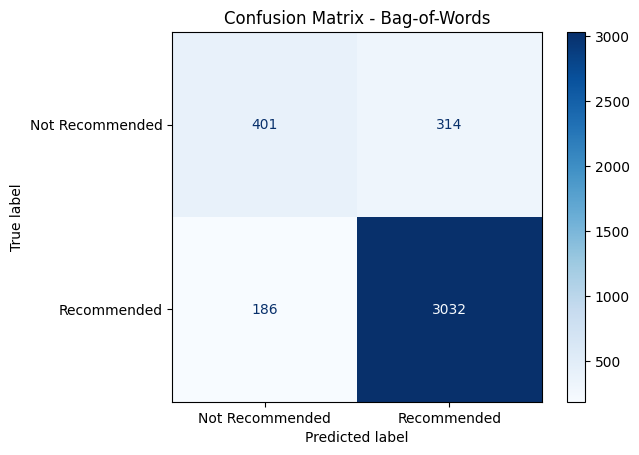

In [8]:
#3.3 Evaluation: Bag-of-Words (BoW)

# Load BoW sparse matrix from count_vectors.txt
rows, cols, data = [], [], []
with open("count_vectors.txt") as f:
    for line in f:
        parts = line.strip().split(',')
        row = int(parts[0][1:])  # Remove '#'
        for pair in parts[1:]:
            col, val = map(int, pair.split(":"))
            rows.append(row)
            cols.append(col)
            data.append(val)

# Load vocab to get correct shape
with open("vocab.txt") as f:
    vocab_size = len(f.readlines())
X_bow = csr_matrix((data, (rows, cols)), shape=(len(df_labels), vocab_size))
train_and_evaluate(X_bow, y, "Bag-of-Words", show_matrix=True)

### 3.4 Evaluation: Unweighted Word Embeddings
In this representation, each review is represented by the average of pre-trained word vectors (Word2Vec). This approach captures the semantic meaning of the words but treats all words equally regardless of importance.

I load the embedding vectors from review_embeddings_unweighted.npy and evaluate them using the same model and function.

 Results for Unweighted Embeddings
Accuracy : 0.8548182049326214
Precision: 0.8714566376648891
Recall   : 0.9648850217526413
F1 Score : 0.9157941306591948


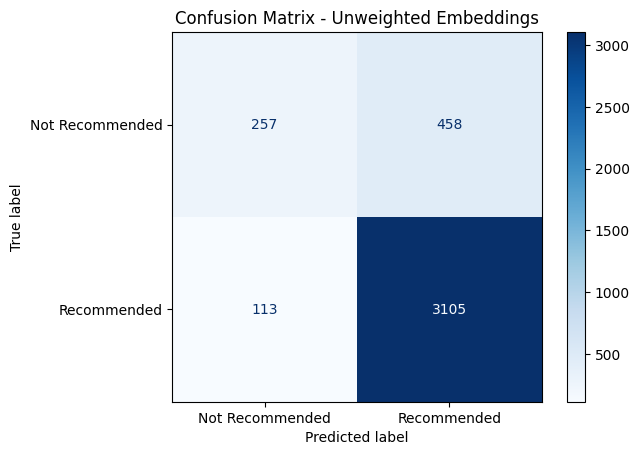

In [9]:
#3.4 Evaluation: Unweighted Word Embeddings
X_unweighted = np.load("review_embeddings_unweighted.npy")
train_and_evaluate(X_unweighted, y, "Unweighted Embeddings", show_matrix=True)

### 3.5 Evaluation: TF-IDF Weighted Word Embeddings
This method enhances word embeddings by applying TF-IDF weighting, giving more importance to informative words in the review. The result is a weighted average vector for each review.

These vectors are loaded from review_embeddings_tfidf.npy and passed through the evaluation pipeline.

 Results for TF-IDF Weighted Embeddings
Accuracy : 0.852275616577676
Precision: 0.8702611625947767
Recall   : 0.9630205096333126
F1 Score : 0.9142941436790087


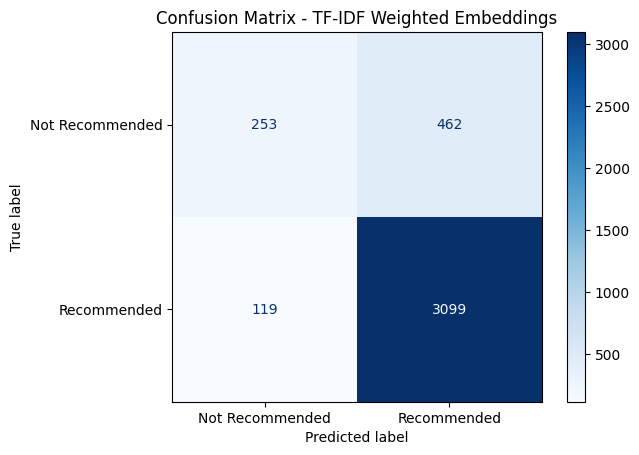

In [10]:
#3.5 Evaluation: TF-IDF Weighted Embeddings
X_tfidf = np.load("review_embeddings_tfidf.npy")
train_and_evaluate(X_tfidf, y, "TF-IDF Weighted Embeddings", show_matrix=True)

#### Q1: Language model comparisons 
Which language model we built previously (based on clothing reviews) performs the best with the 
chosen machine learning model? To answer these questions, you are required to build machine 
learning models based on the feature representations of the documents you generated in Task 2, and 
to perform evaluation on the various model performance.

#### Q1 Answer:
- Logistic Regression was applied consistently to three different text representations: Bag-of-Words, unweighted word embeddings, and TF-IDF weighted embeddings.
-  Among them, the Bag-of-Words model achieved the highest accuracy and F1 score.
-  This suggests that, for this dataset and classifier, Bag-of-Words provides the most effective representation for the recommendation classification task.

#### Q2: Does more information provide higher accuracy?
Let's conduct the experiment...

In [11]:
#step 1 Clean the Title Column
df = pd.read_csv("assignment3.csv") # Load original dataset
with open("stopwords_en.txt", "r") as f: # Load stopwords
    stopwords = set(f.read().splitlines())
token_pattern = r"[a-zA-Z]+(?:[-'][a-zA-Z]+)?"

def clean_title(text): # Clean function for Title column
    if pd.isnull(text):
        return []
    tokens = re.findall(token_pattern, text)
    cleaned = [
        word.lower()
        for word in tokens
        if len(word) >= 2 and word.lower() not in stopwords
    ]
    return cleaned

df['title_tokens'] = df['Title'].apply(clean_title) # Apply cleaning
all_tokens = [word for tokens in df['title_tokens'] for word in tokens] # Remove rare words and top 20 frequent words
word_freq = Counter(all_tokens)
rare_words = {word for word, freq in word_freq.items() if freq == 1}
doc_freq = Counter()
for tokens in df['title_tokens']:
    doc_freq.update(set(tokens))
top_20_common = {word for word, _ in doc_freq.most_common(20)}
words_to_remove = rare_words.union(top_20_common) # Remove both sets
df['title_final'] = df['title_tokens'].apply(lambda tokens: [w for w in tokens if w not in words_to_remove])
df['title_cleaned'] = df['title_final'].apply(lambda tokens: ' '.join(tokens))

# Save cleaned title to CSV
df[['title_cleaned']].to_csv("title_only.csv", index=False)
print(" Saved cleaned titles to title_only.csv")


 Saved cleaned titles to title_only.csv


In [12]:
#Step 2: Combine Title and Review Text

df_title = pd.read_csv("title_only.csv") # Load cleaned title
df_review = pd.read_csv("processed.csv") # Load cleaned review text
df_combined = pd.DataFrame() # Combine cleaned title and review text
df_combined['combined_text'] = df_title['title_cleaned'].fillna('') + ' ' + df_review['processed_text'].fillna('')

# Save to CSV
df_combined.to_csv("title_review_combined.csv", index=False)
print("Saved combined Title + Review Text to title_review_combined.csv")


Saved combined Title + Review Text to title_review_combined.csv


In [13]:
#Step 3: Generate TF-IDF Vectors for title_only and title_review_combined
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np

# Load both cleaned components with aligned indices
df_title = pd.read_csv("title_only.csv")
df_review = pd.read_csv("processed.csv")
df_title = df_title.iloc[:len(df_review)] # Ensure alignment
df_combined = pd.DataFrame() # Combine cleaned title and review text
df_combined['combined_text'] = df_title['title_cleaned'].fillna('') + ' ' + df_review['processed_text'].fillna('')

# Save corrected combined file
df_combined.to_csv("title_review_combined.csv", index=False)
print(" Saved corrected title_review_combined.csv")

# Reload and reprocess TF-IDF
corpus_combined = df_combined['combined_text'].fillna('').tolist()
vectorizer_combined = TfidfVectorizer(tokenizer=lambda x: x.split(), lowercase=False, token_pattern=None)
X_combined_tfidf = vectorizer_combined.fit_transform(corpus_combined)

# Save corrected array
np.save("X_title_review_combined_tfidf.npy", X_combined_tfidf.toarray())
print(" Re-saved X_title_review_combined_tfidf.npy")

 Saved corrected title_review_combined.csv
 Re-saved X_title_review_combined_tfidf.npy


In [14]:
#Step 4: Evaluate Using 5-Fold Cross-Validation
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
import numpy as np
import pandas as pd

# Load labels
df_labels = pd.read_csv("assignment3.csv")
y = df_labels['Recommended IND'].values
X_title = np.load("X_title_tfidf.npy") # Load TF-IDF vectors
X_combined = np.load("X_title_review_combined_tfidf.npy")

# Define model
model = LogisticRegression(max_iter=1000)

# Evaluate Title only
scores_title = cross_val_score(model, X_title, y, cv=5, scoring='accuracy')
print("Title Only - 5-Fold Accuracy:", scores_title)
print("Mean Accuracy (Title):", round(np.mean(scores_title), 4))

# Evaluate Title + Review
scores_combined = cross_val_score(model, X_combined, y, cv=5, scoring='accuracy')
print("Title + Review - 5-Fold Accuracy:", scores_combined)
print("Mean Accuracy (Title + Review):", round(np.mean(scores_combined), 4))


Title Only - 5-Fold Accuracy: [0.85710653 0.86346301 0.86241099 0.85986775 0.86393693]
Mean Accuracy (Title): 0.8614
Title + Review - 5-Fold Accuracy: [0.89143148 0.88558352 0.88835198 0.88351984 0.87868769]
Mean Accuracy (Title + Review): 0.8855


### Q2 Answer:

Three different input scenarios were evaluated using 5-fold cross-validation with the same Logistic Regression model:
- Review Text only (baseline, from Task 2)
- Title only
- Title + Review Text (combined)

The results showed that the Title + Review Text combination achieved the highest average accuracy (88.55%), compared to Review Text only and Title only, which achieved 87.29% and 86.14% respectively.

This confirms that including additional context from the Title improves the model’s ability to predict recommendations. Although the Title alone is less informative than the full review, combining both sources gives a more complete view of customer sentiment, leading to better performance.


## Summary

In Task 2, I transformed preprocessed text into machine-readable formats using three methods:
- Bag-of-Words (BoW): Simple count-based sparse vectors, saved in count_vectors.txt.
- Unweighted Embeddings: Review-level average of Google News word vectors
- TF-IDF Weighted Embeddings: Enhanced semantic vectors using term importance
These representations will be used in Task 3 to train and compare machine learning classifiers for predicting customer recommendations.

In Task 3,
- Logistic Regression was applied to three feature sets—Bag-of-Words, unweighted embeddings, and TF-IDF weighted embeddings—to predict product recommendations. 
- Bag-of-Words performed best, achieving the highest accuracy (87.3%) and F1 score (92.4%). It was selected as the final input for the model.
- Additional testing showed that combining the Title and Review Text improved accuracy further to 88.6%, confirming that more relevant input leads to better predictions.